In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
country_lyrics = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-08-25/country_lyrics.csv')
top_all_writers = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-08-25/top_all_writers.csv')
top_primary_writers = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-08-25/top_primary_writers.csv')
top_producers = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-08-25/top_producers.csv')

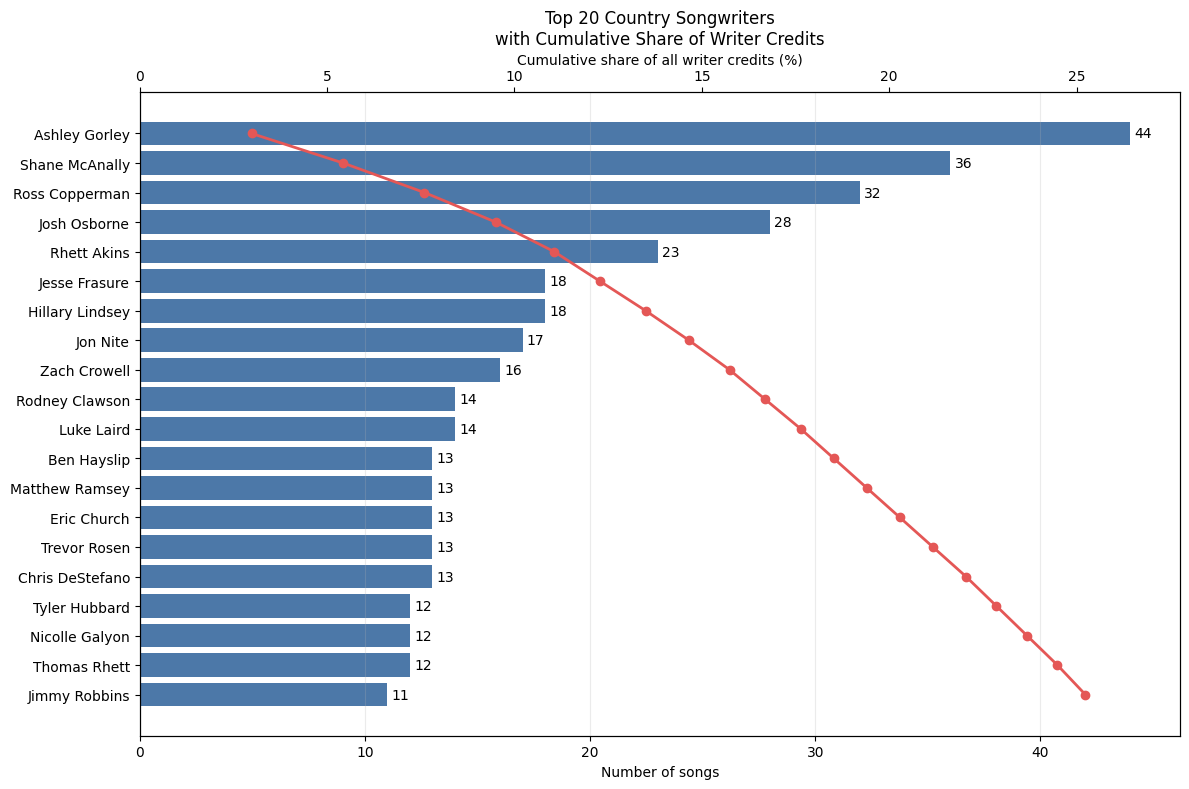

In [4]:
# Pareto chart: leading songwriters and their cumulative share of songs

writers = (
    top_all_writers[top_all_writers["song_count"] > 0]
    .sort_values("song_count", ascending=False)
    .head(20)
    .sort_values("song_count")
)

total_songs = top_all_writers["song_count"].sum()
cumulative_share = writers["song_count"][::-1].cumsum()[::-1] / total_songs * 100

fig, ax1 = plt.subplots(figsize=(12, 8))

bars = ax1.barh(
    writers["writer"],
    writers["song_count"],
    color="#4C78A8"
)

ax1.set_xlabel("Number of songs")
ax1.set_ylabel("")
ax1.set_title("Top 20 Country Songwriters\nwith Cumulative Share of Writer Credits")
ax1.bar_label(bars, padding=3)
ax1.grid(axis="x", alpha=0.25)

ax2 = ax1.twiny()
ax2.plot(
    cumulative_share,
    writers["writer"],
    color="#E45756",
    marker="o",
    linewidth=2
)
ax2.set_xlabel("Cumulative share of all writer credits (%)")
ax2.set_xlim(0, max(cumulative_share) * 1.1)

plt.tight_layout()
plt.show()

# Country Music’s Most Frequent Songwriters

The `top_all_writers` dataset contains songwriting credits for 510 writers. Song counts vary substantially: while some writers are credited with dozens of songs, many appear only once or have no recorded songs in the dataset.

Ashley Gorley leads by a wide margin with 44 songs, followed by Shane McAnally with 36 and Ross Copperman with 32. Josh Osborne ranks fourth with 28 songs, while Rhett Akins completes the top five with 23.

The distribution is highly concentrated among the leading writers. The 20 most prolific writers account for 437 song credits, or approximately 29.6% of the dataset’s 1,474 total credits. This suggests that a relatively small group of songwriters plays a substantial role in the dataset, although songwriting remains broadly distributed across hundreds of contributors.

Overall, the data highlights the importance of a core group of highly active writers in country music. At the same time, the long tail of writers with fewer credits shows that the songwriting landscape includes many occasional or less frequently credited contributors.